In [1]:
#E-commerce Sales Data Analysis and Visualization Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Vinesh\OneDrive\Desktop\ecommerce_sales.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Product,Category,Region,City,Quantity,Unit_Price,Sales,Profit,Payment_Mode,Customer_Type
0,1001,2025-01-05,Laptop,Electronics,South,Chennai,2,55000,110000,12000,UPI,New
1,1002,2025-01-08,Mobile,Electronics,South,Bangalore,3,22000,66000,9000,Card,Returning
2,1003,2025-01-12,Chair,Furniture,North,Delhi,5,4500,22500,3500,Cash,New
3,1004,2025-01-15,Headphones,Electronics,West,Mumbai,4,2500,10000,2000,UPI,Returning
4,1005,2025-01-20,Table,Furniture,South,Chennai,2,8500,17000,2500,Card,New


In [94]:
df.tail()

,Order_ID,Order_Date,Product,Category,Region,City,Quantity,Unit_Price,Sales,Profit,Payment_Mode,Customer_Type,Month,Month_Number,Profit_Margin
35,1036,2025-08-05,Keyboard,Electronics,North,Delhi,12,1800,21600,3600,UPI,New,August,8,16.666667
36,1037,2025-08-11,Mouse,Electronics,West,Mumbai,18,800,14400,2800,Cash,Returning,August,8,19.444444
37,1038,2025-08-17,Sofa,Furniture,South,Hyderabad,2,28000,56000,10000,Card,New,August,8,17.857143
38,1039,2025-08-23,Monitor,Electronics,East,Kolkata,6,15000,90000,12000,UPI,Returning,August,8,13.333333
39,1040,2025-08-29,Desk,Furniture,North,Delhi,5,12000,60000,10000,Card,New,August,8,16.666667


In [6]:
df.describe()

,Order_ID,Quantity,Unit_Price,Sales,Profit
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,1020.500000,5.850000,15010.000000,44275.000000,6577.500000
std,11.690452,4.515216,16050.014778,32089.208586,3989.890269
min,1001.000000,1.000000,800.000000,8000.000000,1600.000000
25%,1010.750000,2.750000,2500.000000,19500.000000,3500.000000
50%,1020.500000,5.000000,10250.000000,35000.000000,5750.000000
75%,1030.250000,8.000000,22000.000000,57000.000000,9250.000000
max,1040.000000,20.000000,55000.000000,132000.000000,18000.000000


In [7]:
df.shape

(40, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       40 non-null     int64 
 1   Order_Date     40 non-null     object
 2   Product        40 non-null     object
 3   Category       40 non-null     object
 4   Region         40 non-null     object
 5   City           40 non-null     object
 6   Quantity       40 non-null     int64 
 7   Unit_Price     40 non-null     int64 
 8   Sales          40 non-null     int64 
 9   Profit         40 non-null     int64 
 10  Payment_Mode   40 non-null     object
 11  Customer_Type  40 non-null     object
dtypes: int64(5), object(7)
memory usage: 3.9+ KB


In [19]:
df.columns

Index(['Order_ID', 'Order_Date', 'Product', 'Category', 'Region', 'City',
       'Quantity', 'Unit_Price', 'Sales', 'Profit', 'Payment_Mode',
       'Customer_Type'],
      dtype='object')

In [22]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Product          0
Category         0
Region           0
City             0
Quantity         0
Unit_Price       0
Sales            0
Profit           0
Payment_Mode     0
Customer_Type    0
dtype: int64

In [24]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df=df.drop_duplicates()

In [27]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Product          0
Category         0
Region           0
City             0
Quantity         0
Unit_Price       0
Sales            0
Profit           0
Payment_Mode     0
Customer_Type    0
dtype: int64

In [35]:
df["Month"]= df["Order_Date"].dt.month_name()

In [36]:
df["Month_Number"] = df["Order_Date"].dt.month

In [42]:
df["Profite_Margine"] = (df["Profit"] / df["Sales"]) *100

In [44]:
df.head()

,Order_ID,Order_Date,Product,Category,Region,City,Quantity,Unit_Price,Sales,Profit,Payment_Mode,Customer_Type,Month,Month_Number,Profit_Margin,Profite_Margine
0,1001,2025-01-05,Laptop,Electronics,South,Chennai,2,55000,110000,12000,UPI,New,January,1,10.909091,10.909091
1,1002,2025-01-08,Mobile,Electronics,South,Bangalore,3,22000,66000,9000,Card,Returning,January,1,13.636364,13.636364
2,1003,2025-01-12,Chair,Furniture,North,Delhi,5,4500,22500,3500,Cash,New,January,1,15.555556,15.555556
3,1004,2025-01-15,Headphones,Electronics,West,Mumbai,4,2500,10000,2000,UPI,Returning,January,1,20.000000,20.000000
4,1005,2025-01-20,Table,Furniture,South,Chennai,2,8500,17000,2500,Card,New,January,1,14.705882,14.705882


In [45]:
total_sales=df["Sales"].sum()
print("Total Sales",total_sales)

Total Sales 1771000


In [46]:
total_profit=df["Profit"].sum()
print("Total Profit",total_profit)

Total Profit 263100


In [50]:
total_orders=df["Order_ID"].nunique()
print("Total Orders",total_orders)

Total Orders 40


In [12]:
product_sales=df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
product_sales

Product
Mobile        396000
Laptop        330000
Monitor       270000
Desk          168000
Sofa          168000
Chair         130500
Table         119000
Headphones     72500
Keyboard       66600
Mouse          50400
Name: Sales, dtype: int64

In [17]:
print("Best Product:", product_sales.idxmax())

Best Product: Mobile


In [30]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Electronics    1185500
Furniture       585500
Name: Sales, dtype: int64

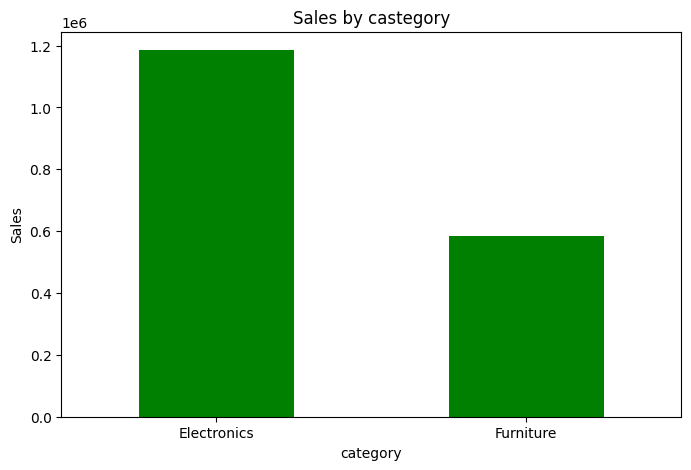

In [31]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar",color="green")

plt.title("Sales by castegory")
plt.xlabel("category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [33]:
region_sales=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
South    736000
West     361400
North    340300
East     333300
Name: Sales, dtype: int64

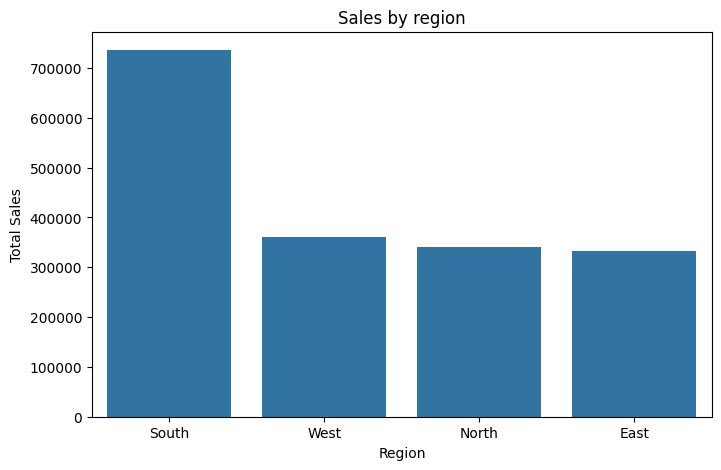

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)
plt.title("Sales by region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()
           
    

In [38]:
city_sales=df.groupby("City")["Sales"].sum().sort_values(ascending=False)

city_sales

City
Mumbai       361400
Delhi        340300
Kolkata      333300
Chennai      319000
Hyderabad    267000
Bangalore    150000
Name: Sales, dtype: int64

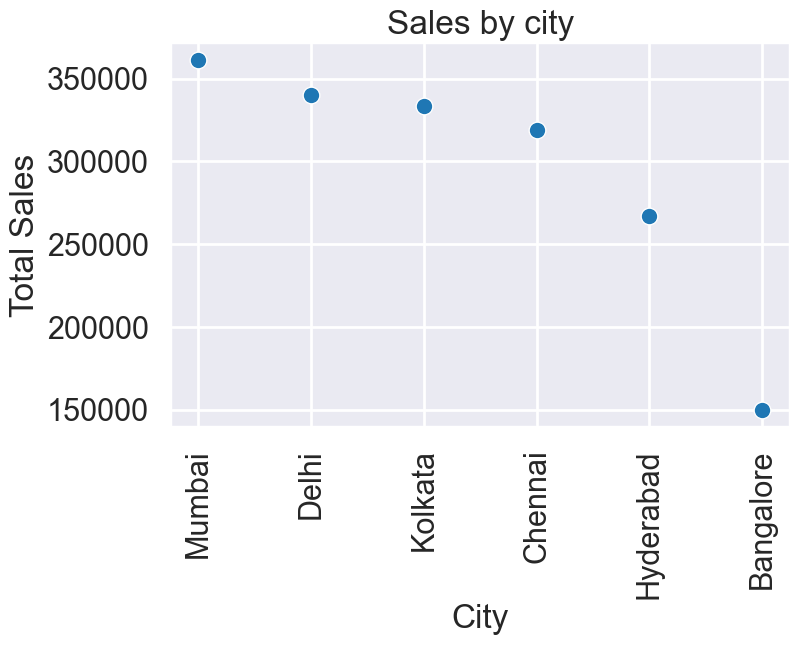

In [51]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")
sns.set_context("poster")
sns.scatterplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title("Sales by city")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()
    

In [61]:
product_quantity = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

product_quantity

Product
Mouse         63
Keyboard      37
Headphones    29
Chair         29
Monitor       18
Mobile        18
Desk          14
Table         14
Laptop         6
Sofa           6
Name: Quantity, dtype: int64

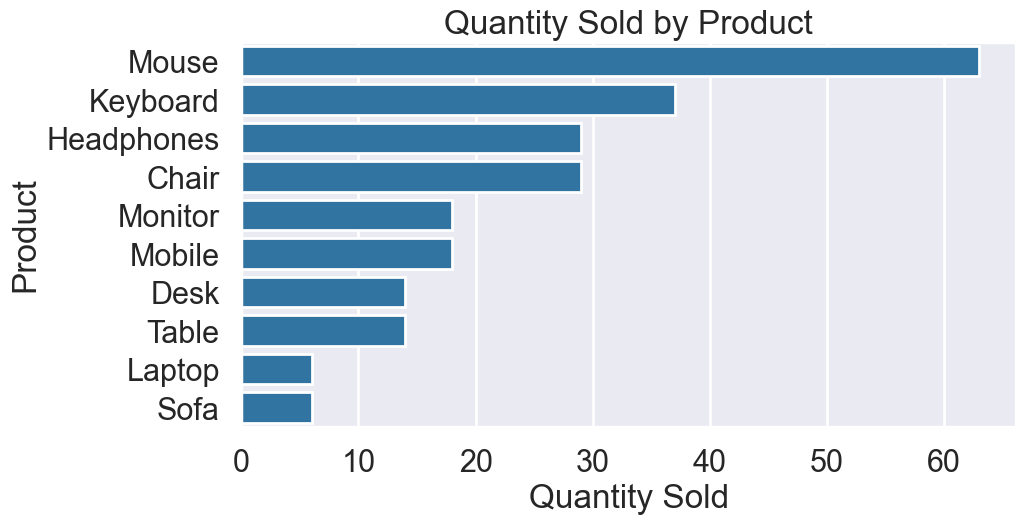

In [62]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=product_quantity.values,
    y=product_quantity.index
)

plt.title("Quantity Sold by Product")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

In [63]:
payment_counts = df["Payment_Mode"].value_counts()

payment_counts

Payment_Mode
UPI     16
Card    16
Cash     8
Name: count, dtype: int64

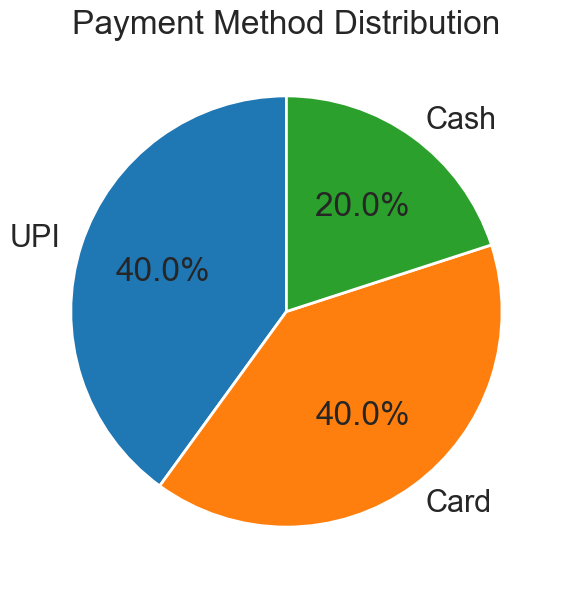

In [64]:
plt.figure(figsize=(7,7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")

plt.show()

In [66]:
customer_counts = df["Customer_Type"].value_counts()

customer_counts

Customer_Type
New          20
Returning    20
Name: count, dtype: int64

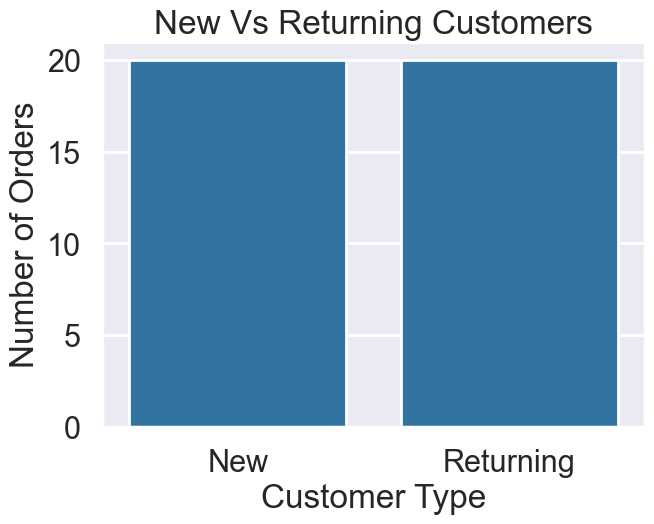

In [67]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=customer_counts.index,
    y=customer_counts.values

)
plt.title("New Vs Returning Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Orders")

plt.show()
    

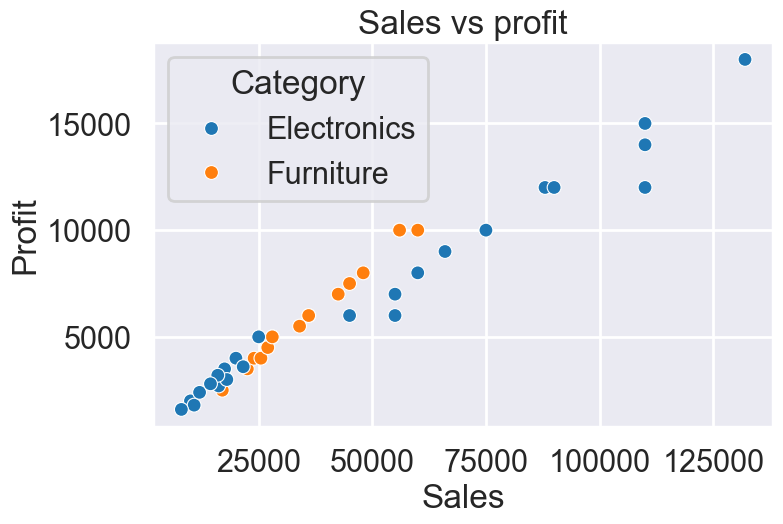

In [72]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")
sns.set_context("poster")
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    s=100
)

plt.title("Sales vs profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [82]:
top_products=(df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5))

top_products

Product
Mobile     396000
Laptop     330000
Monitor    270000
Desk       168000
Sofa       168000
Name: Sales, dtype: int64

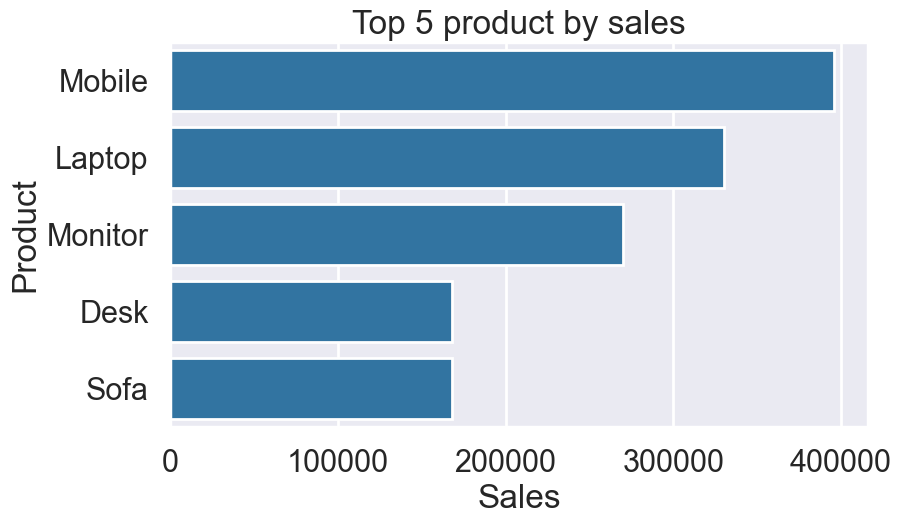

In [83]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 5 product by sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()
           

In [88]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = df["Sales"].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Average Order Value:", average_order_value)

Total Sales: 1771000
Total Profit: 263100
Total Orders: 40
Total Quantity: 234
Average Order Value: 44275.0


In [95]:
print("Highest Sales Category:")
print(df.groupby("Category")["Sales"].sum().idxmax())

print("\nHighest Sales Region:")
print(df.groupby("Region")["Sales"].sum().idxmax())

print("\nBest Selling Product:")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\nMost Used Payment Mode:")
print(df["Payment_Mode"].value_counts().idxmax())

print("\nHighest Profit Product:")
print(df.groupby("Product")["Profit"].sum().idxmax())

Highest Sales Category:
Electronics

Highest Sales Region:
South

Best Selling Product:
Mobile

Most Used Payment Mode:
UPI

Highest Profit Product:
Mobile


In [98]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()
df["Month_Number"] = df["Order_Date"].dt.month
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

#df.to_csv("../Dataset/cleaned_ecommerce_sales.csv", index=False)

print("Cleaned CSV saved successfully!")

Cleaned CSV saved successfully!


In [105]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()
df["Month_Number"] = df["Order_Date"].dt.month
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

df.to_csv(r"C:\Users\Vinesh\OneDrive\Desktop\cleaned_ecommerce_sales.csv", index=False)

print("Cleaned CSV saved successfully!")

Cleaned CSV saved successfully!


In [101]:


cleaned_df.head()

,Order_ID,Order_Date,Product,Category,Region,City,Quantity,Unit_Price,Sales,Profit,Payment_Mode,Customer_Type,Month,Month_Number,Profit_Margin
0,1001,2025-01-05,Laptop,Electronics,South,Chennai,2,55000,110000,12000,UPI,New,January,1,10.909091
1,1002,2025-01-08,Mobile,Electronics,South,Bangalore,3,22000,66000,9000,Card,Returning,January,1,13.636364
2,1003,2025-01-12,Chair,Furniture,North,Delhi,5,4500,22500,3500,Cash,New,January,1,15.555556
3,1004,2025-01-15,Headphones,Electronics,West,Mumbai,4,2500,10000,2000,UPI,Returning,January,1,20.000000
4,1005,2025-01-20,Table,Furniture,South,Chennai,2,8500,17000,2500,Card,New,January,1,14.705882
